In [45]:
%cd 
%cd dev1/scaling-laws-ecnn
import pandas as pd
#import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split

from training.datasets.general.utils import plot_stacked_bar_chart, plot_multiple_bar_charts
# reload
%load_ext autoreload
%autoreload 2

/home/frischs
/home/frischs/dev1/scaling-laws-ecnn
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [43]:
path = "../../Data/frischs/datasets/DeepDRiD/DeepDRiD-master/regular_fundus_images/regular-fundus-training"
csv_file = "regular-fundus-training.csv"

df = pd.read_csv(path + "/" + csv_file)
df.head()

,patient_id,image_id,image_path,Overall quality,left_eye_DR_Level,right_eye_DR_Level,patient_DR_Level,Clarity,Field definition,Artifact
0,1,1_l1,\regular-fundus-training\1\1_l1.jpg,0,0.0,NaN,0,8,8,4
1,1,1_l2,\regular-fundus-training\1\1_l2.jpg,0,0.0,NaN,0,8,8,0
2,1,1_r1,\regular-fundus-training\1\1_r1.jpg,0,NaN,0.0,0,8,8,4
3,1,1_r2,\regular-fundus-training\1\1_r2.jpg,0,NaN,0.0,0,10,8,0
4,2,2_l1,\regular-fundus-training\2\2_l1.jpg,0,2.0,NaN,2,10,8,6


In [49]:
path = "../../Data/frischs/datasets/DeepDRiD/DeepDRiD-master/regular_fundus_images/Online-Challenge1&2-Evaluation"
csv_file = "Challenge2_labels.xlsx"

df = pd.read_excel(path + "/" + csv_file)
df.head()

,image_id,Overall quality,Artifact,Clarity,Field definition
0,347_l1,0,4,6,8
1,347_l2,0,0,10,6
2,347_r1,0,8,6,8
3,347_r2,0,6,8,6
4,353_l1,0,6,6,8


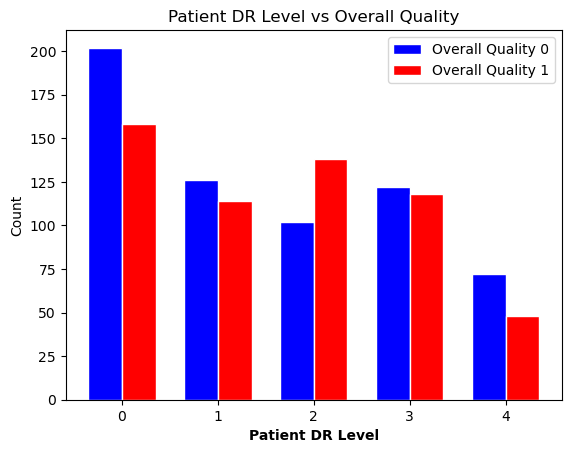

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'Patient DR Level vs Overall Quality'}, xlabel='Patient DR Level', ylabel='Count'>)

In [44]:
plot_stacked_bar_chart(df, 'whole Patient DR Level vs Overall Quality')
#train_df, val_df = train_test_split(df[["patient_id", "Overall quality", "patient_DR_Level"]], test_size=0.25, random_state=42, stratify=df[["Overall quality", "patient_DR_Level"]])



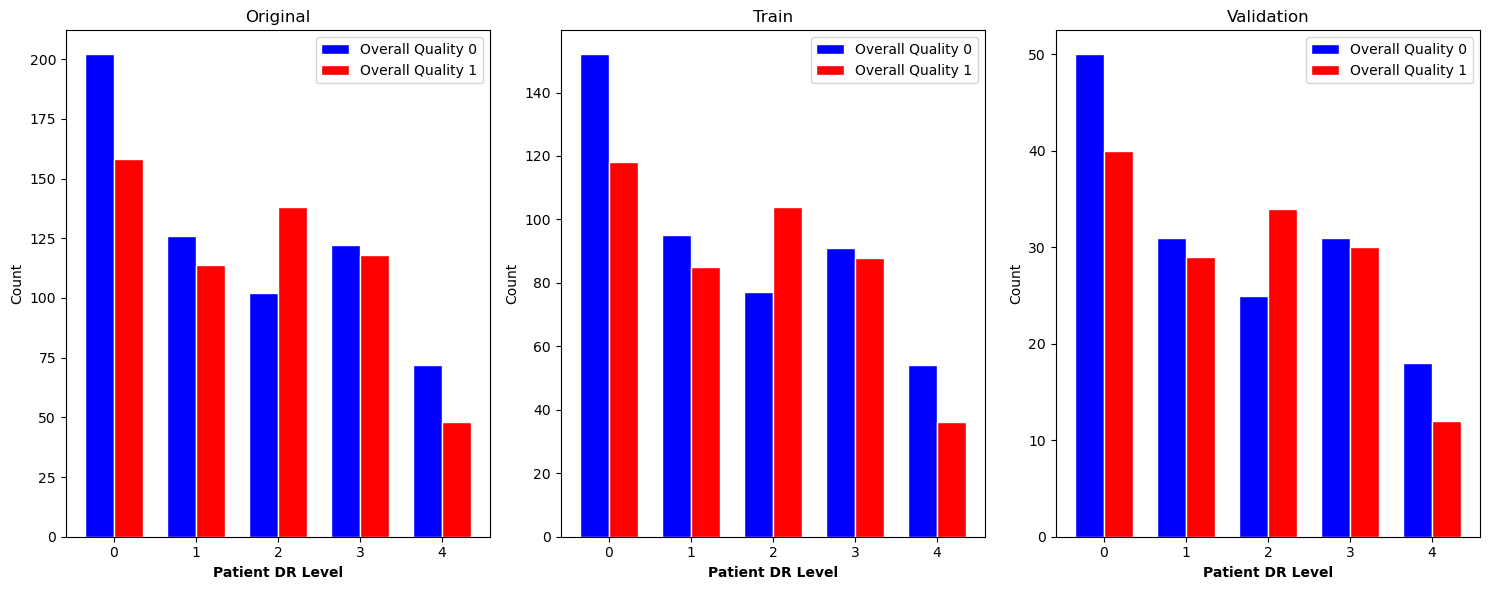

In [46]:
train_df, val_df = train_test_split(df[["patient_id", "Overall quality", "patient_DR_Level"]], test_size=0.25, random_state=42, stratify=df[["Overall quality", "patient_DR_Level"]])

plot_multiple_bar_charts([df, train_df, val_df], ['Original', 'Train', 'Validation'])

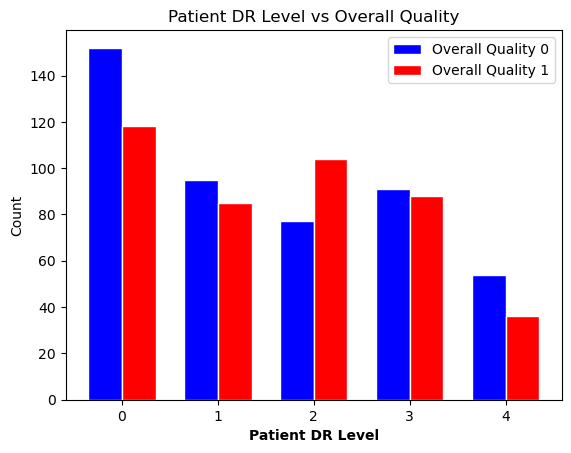

In [41]:
import matplotlib.pyplot as plt
import numpy as np
from pandas import DataFrame

def plot_stacked_bar_chart(df: DataFrame):
    # Count the occurrences of each pair (Overall quality, patient_DR_Level)
    grouped_data = df[['Overall quality', 'patient_DR_Level']].groupby("patient_DR_Level").value_counts().unstack().fillna(0)
    
    # Extract values for each quality level
    quality_0 = grouped_data.loc[:, 0].values
    quality_1 = grouped_data.loc[:, 1].values

    # Create the bar chart
    barWidth = 0.35
    fig, ax = plt.subplots()

    # Set position of bar on X axis
    r1 = np.arange(len(quality_0))
    r2 = [x + barWidth for x in r1]

    # Make the plot
    plt.bar(r1, quality_0, color='b', width=barWidth, edgecolor='white', label='Overall Quality 0')
    plt.bar(r2, quality_1, color='r', width=barWidth, edgecolor='white', label='Overall Quality 1')

    # Add labels, title, and axes ticks
    plt.xlabel('Patient DR Level', fontweight='bold')
    plt.ylabel('Count')
    plt.title('Patient DR Level vs Overall Quality')
    plt.xticks([r + barWidth / 2 for r in range(len(quality_0))], grouped_data.index.tolist())

    # Add legend
    plt.legend()

    # Show the plot
    plt.show()

# Example usage
#train_df = # Your training DataFrame here
plot_stacked_bar_chart(train_df)


In [39]:

train_df, val_df = train_test_split(df[["patient_id", "Overall quality", "patient_DR_Level"]], test_size=0.25, random_state=42, stratify=df[["Overall quality", "patient_DR_Level"]])
print("train\n", train_df[['Overall quality', 'patient_DR_Level']].groupby("patient_DR_Level").value_counts())

train
 patient_DR_Level  Overall quality
0                 0                  152
                  1                  118
1                 0                   95
                  1                   85
2                 1                  104
                  0                   77
3                 0                   91
                  1                   88
4                 0                   54
                  1                   36
dtype: int64


In [29]:
df # [["patient_id", "patient_DR_Level"]].drop_duplicates().groupby("patient_DR_Level").count()

,patient_id,image_id,image_path,Overall quality,left_eye_DR_Level,right_eye_DR_Level,patient_DR_Level,Clarity,Field definition,Artifact
0,1,1_l1,\regular-fundus-training\1\1_l1.jpg,0,0.0,NaN,0,8,8,4
1,1,1_l2,\regular-fundus-training\1\1_l2.jpg,0,0.0,NaN,0,8,8,0
2,1,1_r1,\regular-fundus-training\1\1_r1.jpg,0,NaN,0.0,0,8,8,4
3,1,1_r2,\regular-fundus-training\1\1_r2.jpg,0,NaN,0.0,0,10,8,0
4,2,2_l1,\regular-fundus-training\2\2_l1.jpg,0,2.0,NaN,2,10,8,6
...,...,...,...,...,...,...,...,...,...,...
1195,329,329_r2,\regular-fundus-training\329\329_r2.jpg,1,NaN,1.0,1,8,10,0
1196,330,330_l1,\regular-fundus-training\330\330_l1.jpg,0,1.0,NaN,1,10,8,0
1197,330,330_l2,\regular-fundus-training\330\330_l2.jpg,0,1.0,NaN,1,10,8,0
1198,330,330_r1,\regular-fundus-training\330\330_r1.jpg,1,NaN,0.0,1,10,8,0


In [16]:
path = "../../Data/frischs/datasets/DeepDRiD/DeepDRiD-master/regular_fundus_images/regular-fundus-training"
csv_file = "regular-fundus-training.csv"

df = pd.read_csv(path + "/" + csv_file)
df

images = df["image_path"].tolist()
images

#images = [path + "/" + image for image in images]
#
#labels = df["Overall quality"].tolist()
#labels

['\\regular-fundus-training\\1\\1_l1.jpg',
 '\\regular-fundus-training\\1\\1_l2.jpg',
 '\\regular-fundus-training\\1\\1_r1.jpg',
 '\\regular-fundus-training\\1\\1_r2.jpg',
 '\\regular-fundus-training\\2\\2_l1.jpg',
 '\\regular-fundus-training\\2\\2_l2.jpg',
 '\\regular-fundus-training\\2\\2_r1.jpg',
 '\\regular-fundus-training\\2\\2_r2.jpg',
 '\\regular-fundus-training\\3\\3_l1.jpg',
 '\\regular-fundus-training\\3\\3_l2.jpg',
 '\\regular-fundus-training\\3\\3_r1.jpg',
 '\\regular-fundus-training\\3\\3_r2.jpg',
 '\\regular-fundus-training\\4\\4_l1.jpg',
 '\\regular-fundus-training\\4\\4_l2.jpg',
 '\\regular-fundus-training\\4\\4_r1.jpg',
 '\\regular-fundus-training\\4\\4_r2.jpg',
 '\\regular-fundus-training\\5\\5_l1.jpg',
 '\\regular-fundus-training\\5\\5_l2.jpg',
 '\\regular-fundus-training\\5\\5_r1.jpg',
 '\\regular-fundus-training\\5\\5_r2.jpg',
 '\\regular-fundus-training\\6\\6_l1.jpg',
 '\\regular-fundus-training\\6\\6_l2.jpg',
 '\\regular-fundus-training\\6\\6_r1.jpg',
 '\\regular

In [27]:
def get_images_and_labels(df: pd.DataFrame, path: str):
    def replace_backslashes(input_string):
        # Split the string by backslashes and get everything after the second backslash
        parts = input_string.split("\\", 2)
        if len(parts) >= 3:
            result = parts[2].replace("\\", "/")
            return result
        else:
            raise ValueError("String does not contain enough backslashes.")

    images = df["image_path"].tolist()
    images = [path + "images/" + replace_backslashes(image) for image in images]
    labels = df["Overall quality"].tolist()
    labels
    return images, labels

images, labels = get_images_and_labels(df, path)
images[:5]

['/home/stefan/Downloadsimages/1/1_l1.jpg',
 '/home/stefan/Downloadsimages/1/1_l2.jpg',
 '/home/stefan/Downloadsimages/1/1_r1.jpg',
 '/home/stefan/Downloadsimages/1/1_r2.jpg',
 '/home/stefan/Downloadsimages/2/2_l1.jpg']

In [24]:
# Input string
input_string = "\\regular-fundus-training\\1\\1_l1.jpg"

# Split the string by backslashes and get everything after the second backslash
parts = input_string.split("\\", 2)
if len(parts) >= 3:
    result = parts[2].replace("\\", "/")
    print(result)
else:
    print("String does not contain enough backslashes.")


1/1_l1.jpg
